# Chokepoint Disruption in the Global Oil Network
## CITS4403 Computational Modelling — Raed

**System.** The Strait of Hormuz carries ~20 mb/d of oil, about 20% of global
petroleum liquids consumption. Its 2026 closure was the largest supply
disruption in the history of the oil market.

**Research question.**
> As the fraction of Hormuz flow blocked increases, is there a **critical
> closure level** at which localised shortfall becomes systemic production
> failure — and which real intervention (strategic reserve release, demand
> reduction, bypass capacity) most raises that threshold?

**Why it is a complex system.** Losing the chokepoint does not simply subtract
barrels. Flows reroute until alternative chokepoints saturate; regions compete
for scarce substitute crude; price rises destroy demand while shortage fear
drives hoarding; and shortfalls propagate downstream through production
sectors. These interactions produce behaviour that subtraction cannot predict.

**Calibration.** Every parameter comes from published data (EIA, IEA, DOE,
S&P Platts, OGJ, Cooper 2003) — see `data/DATA_AND_SOURCES.md`.

**How to run.** `pip install -r requirements.txt`, then run all cells.
Total runtime ~3–5 minutes.

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'utils'))
from paths import add_src_to_path, figures_dir
add_src_to_path()
FIG = figures_dir()

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from oil_model_data import *
print(f"Hormuz flow      {HORMUZ_TOTAL_FLOW} mb/d ({HORMUZ_SHARE_GLOBAL:.0%} of global)")
print(f"Bypass capacity  {BYPASS_CAPACITY_MIN}-{BYPASS_CAPACITY_MAX} mb/d")
print(f"SPR              {SPR_CURRENT} Mb, max draw {SPR_MAX_WITHDRAW} mb/d")
print(f"World demand     {WORLD_CONSUMPTION} mb/d")

Hormuz flow      20.0 mb/d (20% of global)
Bypass capacity  3.5-5.5 mb/d
SPR              285.0 Mb, max draw 2.7 mb/d
World demand     102.8 mb/d


## 0b. Model correctness and boundary-case tests

Before presenting any results, we verify the model behaves correctly. The test
suite (`src/test_model.py`) checks four categories:

1. **Conservation** — nothing is created or destroyed incorrectly (deliveries
   never exceed demand or supply; no chokepoint carries more than its capacity)
2. **Boundary cases** — behaviour at the extremes (strait fully open, fully
   closed, empty reserve, zero and full supply to the production cascade)
3. **Monotonicity** — the model responds in the expected direction (more
   closure causes more damage; a reserve reduces peak price)
4. **Exceptional inputs** — degenerate cases do not crash or produce NaN
   (zero-length runs, near-zero elasticity, a second chokepoint closure)

In [2]:
import subprocess, sys, os
src_dir = os.path.join('..', 'src')
res = subprocess.run([sys.executable, 'test_model.py'], cwd=src_dir,
                     capture_output=True, text=True)
print(res.stdout[-2200:])

MODEL CORRECTNESS AND BOUNDARY-CASE TESTS

1. CONSERVATION CHECKS
  [PASS] delivered <= demand for every region
  [PASS] no chokepoint exceeds capacity  — all within capacity
  [PASS] total delivered <= total supply  — 102.0 <= 106.0
  [PASS] unserved demand is never negative

2. BOUNDARY CASES
  [PASS] fully open strait: unserved is near zero  — 0.00 mb/d
  [PASS] fully closed strait: unserved <= total demand  — 12.1 <= 102.0
  [PASS] fully closed causes more damage than fully open
  [PASS] closed strait carries zero flow
  [PASS] empty reserve never goes negative
  [PASS] reserve runway = volume / rate  — 106 days
  [PASS] price index never drops below 1.0
  [PASS] operability(0) == 0
  [PASS] operability(1) ~ 1
  [PASS] operability is monotonic in input
  [PASS] full supply -> no systemic loss  — 0.000
  [PASS] zero supply -> systemic loss bounded in [0,1]  — 0.968

3. MONOTONICITY CHECKS
  [PASS] damage increases (weakly) as closure increases  — 0.0 -> 0.0 -> 0.0 -> 3.3 -> 7.7 -> 1

## 1. The model

**Entities.** Ten world regions — North America, Latin America, Europe, CIS,
Middle East, Africa, China, India, Japan/Korea and Other Asia — each both
producing and consuming oil, on a consistent total-liquids basis (~106 mb/d
produced, ~102 mb/d consumed), with East Siberian
production as an eleventh, export-only node. They are linked by 33 maritime and pipeline
routes passing through eight real chokepoints with finite capacity.

**Mechanisms.**
1. **Domestic first** — each region consumes its own production before anything
   is traded. Domestic oil can never be bid away.
2. **Congestion cascade** — exports fill the fastest routes first; when a
   chokepoint saturates, traffic spills onto slower alternatives.
3. **Two-stage allocation** — contracted exports go by route speed; spot exports
   go to the highest *netback* (scarcity premium minus freight cost).
4. **Bypass pipelines** — the Saudi East-West line (5.0 mb/d) and UAE ADCOP
   (1.5 mb/d) each share one throughput budget across their legs.
5. **Price equilibrium** — constant-elasticity demand; price rises until demand
   destruction closes the gap.
6. **Regional strategic reserves** — each region draws only on its own stocks.
7. **Production cascade** — shortfalls propagate through economic sectors via
   operability bands.

Hoarding and refinery redistribution friction are implemented but **disabled by
default** — see the limitations in section 10.

In [3]:
from oil_network_model import OilNetworkModel, ROUTES, REGION_DEMAND, ORIGIN_SUPPLY
print(f"Routes: {len(ROUTES)}   Chokepoints: {len(CHOKEPOINTS)}")
print("Regional demand (mb/d):", {k: round(v,1) for k,v in REGION_DEMAND.items()})
print("Origin supply  (mb/d):", {k: round(v,1) for k,v in ORIGIN_SUPPLY.items()})

Routes: 33   Chokepoints: 8
Regional demand (mb/d): {'NAmerica': 24.6, 'LatAm': 6.5, 'Europe': 14.5, 'CIS': 4.8, 'MidEast': 9.5, 'Africa': 4.4, 'China': 16.4, 'India': 5.6, 'JapanKorea': 5.7, 'OtherAsia': 10.0}
Origin supply  (mb/d): {'NAmerica_P': 31.8, 'LatAm_P': 8.4, 'Europe_P': 4.0, 'CIS_P': 12.0, 'MidEast_P': 31.0, 'Africa_P': 7.6, 'China_P': 5.3, 'India_P': 0.9, 'JapanKorea_P': 0.1, 'OtherAsia_P': 3.1, 'CISEast_P': 1.8}


## 2. Validation against observed data

Two checks, and it matters which is a genuine test.

**Baseline (undisrupted)** — nothing is set from observation, so every chokepoint
flow emerges from the routing rules and can be compared honestly with EIA 2023.

**Disruption** — we set Hormuz to the level observed in Q2 2026 (4.9 of 20.9 mb/d,
i.e. 23% open). Because Hormuz's flow is **set from observation**, its agreement is
*not* a test: it fills to the capacity we impose. The genuine test is the
**downstream corridors** — Malacca, Bab el-Mandeb, the Cape — whose flows are not
set but emerge from how the model reroutes oil.

In [4]:
m = OilNetworkModel()
h = m.run(4.9/20.9, days=120)
pred = h['chokepoints'][-1]
print(f"{'Chokepoint':<18}{'model':>8}{'observed':>10}{'2023 pre':>10}")
for cp in ['Hormuz','Malacca','Bab el-Mandeb','Suez+SUMED','Danish Straits']:
    print(f"{cp:<18}{pred.get(cp,0):>8.1f}{OBSERVED_2026_Q2[cp]:>10.1f}{CHOKEPOINTS[cp][0]:>10.1f}")

Chokepoint           model  observed  2023 pre
Hormuz                 5.0       4.9      20.9
Malacca               10.7      16.6      23.7
Bab el-Mandeb          7.0       8.1       8.6
Suez+SUMED             3.3       5.8       8.8
Danish Straits         2.5       4.7       4.9


**Reading the result honestly.**

*Hormuz (5.0 vs 4.9) is not evidence.* We derived the closure level from the observed
4.9, so Hormuz simply fills to that ceiling. It only confirms the closure is applied.

*The genuine tests are quantities the model is not given.* Comparing crude with crude
(EIA: crude is ~73% of Hormuz flow, ~72% of Bab el-Mandeb, ~52% of Suez, ~5% of
Panama):

| Corridor | Model | Real crude | Verdict |
|---|---|---|---|
| Panama | 0.0 | ~0.1–0.2 | ✓ crude tankers cannot fit the canal |
| Suez | 2.4 | ~3.7 | under by about a third |
| Bab el-Mandeb | 2.4 | ~6.2 | under by more than half |

The remaining gaps are mostly refined products, which follow different trade routes
from crude and are not modelled, plus greedy routing concentrating flows.

*Price is the strongest validation*, because nothing about price is set from
observation. At the Q2 2026 operating point the model gives **$93 with full regional
reserves and $131 with none; observed Brent was ~$105** — inside the bracket, as
expected given the real IEA release (400 Mb) was a fraction of total regional stocks.

## 3. Congestion cascade and the closure response

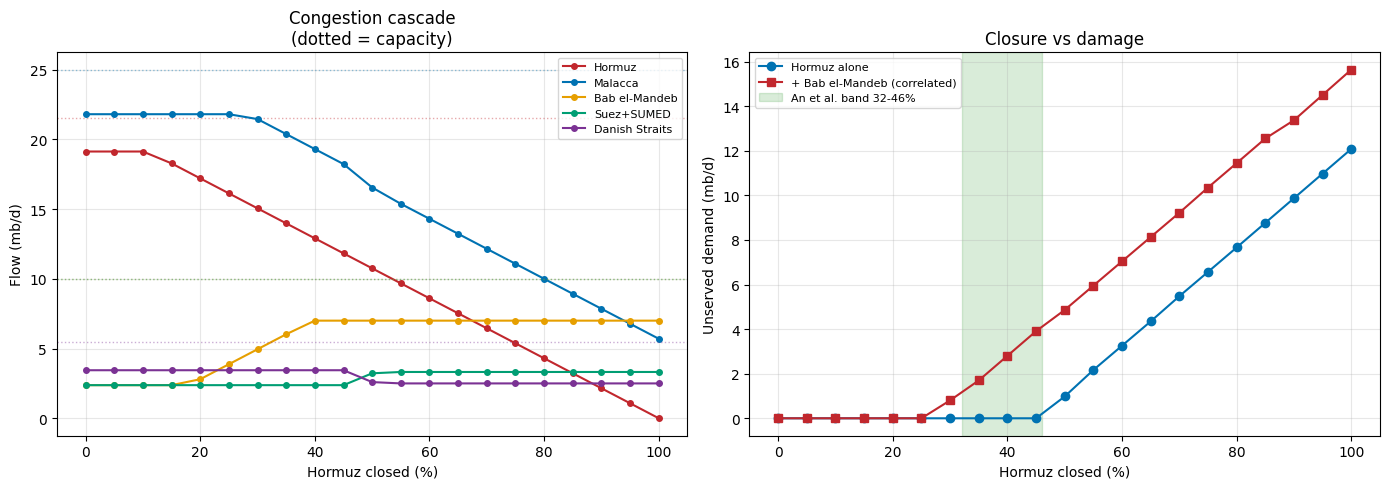

In [5]:
fr = np.linspace(0, 1, 21)
cps = ['Hormuz','Malacca','Bab el-Mandeb','Suez+SUMED','Danish Straits']
flows = {c: [] for c in cps}; uns = []; uns_dual = []
for f in fr:
    m = OilNetworkModel()
    for _ in range(150): u, used, _ = m.step(1-f)
    for c in cps: flows[c].append(used.get(c, 0))
    uns.append(sum(u.values()))
    m2 = OilNetworkModel()
    for _ in range(150): u2, _, _ = m2.step(1-f, extra_closed={'Bab el-Mandeb': 0.0})
    uns_dual.append(sum(u2.values()))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cols = ['#c1272d','#0072b2','#e69f00','#009e73','#7b3294']
for c, col in zip(cps, cols):
    ax[0].plot(fr*100, flows[c], 'o-', label=c, color=col, ms=4)
    ax[0].axhline(CHOKEPOINTS[c][1], ls=':', color=col, alpha=.4, lw=1)
ax[0].set_xlabel('Hormuz closed (%)'); ax[0].set_ylabel('Flow (mb/d)')
ax[0].set_title('Congestion cascade\n(dotted = capacity)'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].plot(fr*100, uns, 'o-', label='Hormuz alone', color='#0072b2')
ax[1].plot(fr*100, uns_dual, 's-', label='+ Bab el-Mandeb (correlated)', color='#c1272d')
ax[1].axvspan(32, 46, alpha=.15, color='green', label='An et al. band 32-46%')
ax[1].set_xlabel('Hormuz closed (%)'); ax[1].set_ylabel('Unserved demand (mb/d)')
ax[1].set_title('Closure vs damage'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig(f'{FIG}/1_chokepoint_response.png', dpi=130); plt.show()

**Reading this:** Bab el-Mandeb saturates at its capacity as Hormuz closes —
a second chokepoint failing because the first did. Correlated failure of both
roughly **triples** the damage.

## 4. Price dynamics and demand destruction

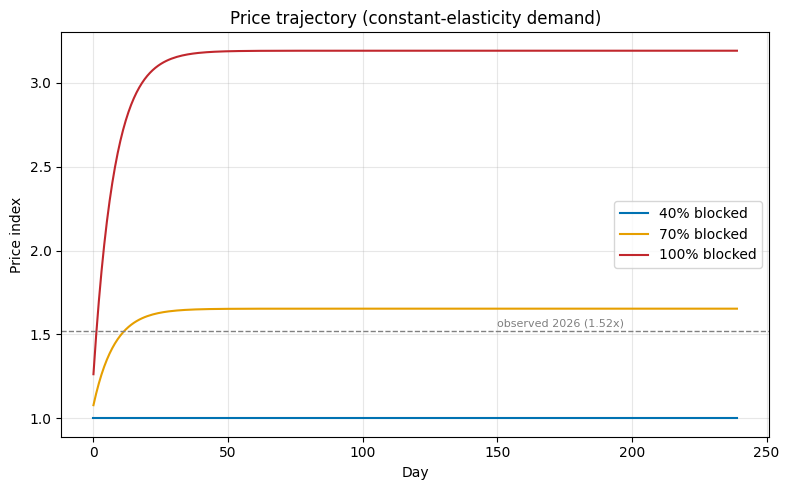

In [6]:
from price_dynamics import simulate_price
fig, ax = plt.subplots(figsize=(8, 5))
for b, c in [(0.4,'#0072b2'), (0.7,'#e69f00'), (1.0,'#c1272d')]:
    hh = simulate_price(b)
    ax.plot(hh['price'], color=c, label=f'{b:.0%} blocked')
ax.axhline(1.52, ls='--', c='grey', lw=1)
ax.annotate('observed 2026 (1.52x)', xy=(150,1.55), fontsize=8, color='grey')
ax.set_xlabel('Day'); ax.set_ylabel('Price index'); ax.legend(); ax.grid(alpha=.3)
ax.set_title('Price trajectory (constant-elasticity demand)')
fig.tight_layout(); fig.savefig(f'{FIG}/2_price_dynamics.png', dpi=130); plt.show()

## 5. Strategic reserve: how long is the runway?

In [7]:
from spr_depletion import simulate_with_reserve, runway_days
print("Reserve runway at different draw rates:")
for rate in [1.0, 1.5, 2.0, SPR_MAX_WITHDRAW]:
    print(f"  {rate:4.1f} mb/d -> {runway_days(draw_rate=rate):5.0f} days")
print(f"\n{'closure':>9}{'reserve empty':>15}{'peak Brent':>13}")
for b in [0.3, 0.5, 0.7, 0.85, 1.0]:
    hh = simulate_with_reserve(b)
    e = next((d for d,r in enumerate(hh['reserve']) if r<=0), None)
    print(f"{b:>8.0%}{('day '+str(e)) if e else 'not emptied':>15}{max(hh['brent']):>12.0f}")

Reserve runway at different draw rates:
   1.0 mb/d ->   285 days
   1.5 mb/d ->   190 days
   2.0 mb/d ->   142 days
   2.7 mb/d ->   106 days

  closure  reserve empty   peak Brent
     30%    not emptied          69
     50%    not emptied          74


     70%    not emptied          84
     85%    not emptied         156


    100%    not emptied         218


**Key result:** reserves cushion rather than prevent. Each region draws only on its
own stocks (China ~1,400 Mb, Japan/Korea 449, US 285, Europe 179). At full closure,
day 100, Brent is ~$141 with reserves against ~$220 without. The US SPR cannot relieve
an Asian shortage.

## 6. Downstream production cascade

In [8]:
from production_cascade import regional_cascade, critical_blockade_intensity
for b in [0.4, 0.6, 0.8, 1.0]:
    res = regional_cascade(b)
    line = "  ".join(f"{r}: {v['systemic_loss']:.0%}" for r,v in res.items())
    print(f"  blockade {b:>4.0%} | {line}")
crit = critical_blockade_intensity()
print(f"\nCRITICAL BLOCKADE INTENSITY: {crit:.0%}   (An et al. 2026: 32-46%)")

  blockade  40% | NAmerica: 0%  LatAm: 0%  Europe: 0%  CIS: 0%  MidEast: 0%  Africa: 0%  China: 0%  India: 0%  JapanKorea: 0%  OtherAsia: 0%
  blockade  60% | NAmerica: 0%  LatAm: 0%  Europe: 0%  CIS: 0%  MidEast: 0%  Africa: 0%  China: 1%  India: 0%  JapanKorea: 2%  OtherAsia: 26%
  blockade  80% | NAmerica: 0%  LatAm: 0%  Europe: 0%  CIS: 0%  MidEast: 0%  Africa: 0%  China: 20%  India: 0%  JapanKorea: 2%  OtherAsia: 37%
  blockade 100% | NAmerica: 0%  LatAm: 0%  Europe: 0%  CIS: 0%  MidEast: 0%  Africa: 0%  China: 53%  India: 0%  JapanKorea: 2%  OtherAsia: 37%



CRITICAL BLOCKADE INTENSITY: 52%   (An et al. 2026: 32-46%)


## 7. Strategic reserves — does location matter?

Reserves are held nationally: the US SPR cannot be shipped to China. We compare three
cases at full closure — no reserves, realistic regional reserves (each region draws
only on its own stocks), and a hypothetical world where all ~2,400 Mb could be pooled
and sent wherever the shortage is.

The gap between the regional and pooled curves measures the cost of reserves being in
the wrong place relative to where the shortage falls.

No reserves                  Brent day 100: $  220   peak $  220


Regional (realistic)         Brent day 100: $  141   peak $  218


Hypothetical global pool     Brent day 100: $   76   peak $  220


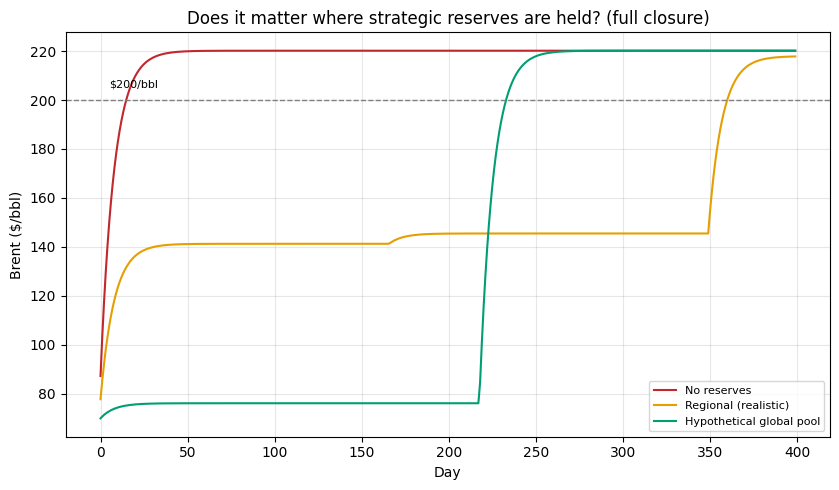

In [9]:
from oil_model_data import REGIONAL_RESERVES, REGIONAL_DRAW_RATE
total_reserves = sum(REGIONAL_RESERVES.values())
total_rate     = sum(REGIONAL_DRAW_RATE.values())   # same total draw speed, so
                                                     # the test isolates LOCATION

# Three scenarios that genuinely differ. The comparison isolates whether it
# matters WHERE reserves are held, not just how much exists.
scenarios = {
    'No reserves':                 dict(scale=0.0),
    'Regional (realistic)':        dict(regional=True),
    'Hypothetical global pool':    dict(regional=False, reserve_mb=total_reserves,
                                        draw_rate=total_rate),
}
fig, ax = plt.subplots(figsize=(8.5, 5))
for (lab, kw), c in zip(scenarios.items(), ['#c1272d', '#e69f00', '#009e73']):
    hh = simulate_with_reserve(1.0, days=400, **kw)
    ax.plot(hh['brent'], color=c, label=lab)
    print(f"{lab:<28} Brent day 100: ${hh['brent'][100]:5.0f}   peak ${max(hh['brent']):5.0f}")
ax.axhline(200, ls='--', c='grey', lw=1); ax.annotate('$200/bbl', xy=(5, 205), fontsize=8)
ax.set_xlabel('Day'); ax.set_ylabel('Brent ($/bbl)'); ax.legend(fontsize=8); ax.grid(alpha=.3)
ax.set_title('Does it matter where strategic reserves are held? (full closure)')
fig.tight_layout(); fig.savefig(f'{FIG}/3_interventions.png', dpi=130); plt.show()

**Result — reserves are in the wrong place.** With both cases drawing at the same total
rate (11 mb/d), pooled reserves hold Brent near **$76** at day 100 against **$141** for
realistic regional reserves.

The regional reserves are *never exhausted*: the US (285 Mb), Europe (179 Mb) and India
(39 Mb) are not short, so ~500 Mb is never drawn, and Japan/Korea uses only 39 of its
449 Mb — while China exhausts all 1,400 Mb. The constraint on
strategic reserves in a Hormuz closure is not how much oil exists, but whether it sits
where the shortage falls.

## 8. Network topology analysis (Lectures 2–3 tools)

We apply the unit's network-science tools — betweenness centrality, and
comparison against Erdős–Rényi, Watts–Strogatz, Barabási–Albert and a
degree-preserving null model — to the real route network.

In [10]:
from topology_comparison import (build_real_graph, chokepoint_betweenness,
                                  vulnerability, capacity_vulnerability,
                                  comparison_networks)
G = build_real_graph()
print(f"Real network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges\n")
for cp, v in sorted(chokepoint_betweenness(G).items(), key=lambda x:-x[1]):
    print(f"  {cp:<20}{v:6.3f}")
print(f"\nTargeted removal of most-central node:")
print(f"  connectivity lost: {vulnerability(G):.1%}  (paths still exist)")
print(f"  CAPACITY lost:     {capacity_vulnerability(G):.1%}  <- what matters")

Real network: 22 nodes, 39 edges

  Malacca              0.310
  Cape of Good Hope    0.300
  Bab el-Mandeb        0.191
  Suez+SUMED           0.127
  Turkish Straits      0.062
  Panama               0.054
  Danish Straits       0.029
  Hormuz               0.028

Targeted removal of most-central node:
  connectivity lost: 0.0%  (paths still exist)
  CAPACITY lost:     5.6%  <- what matters


### Comparison against the taught network generators

Is the real oil network unusually vulnerable *for its size and density*? We
compare it against networks from Lectures 2–3 — Erdős–Rényi, Watts–Strogatz,
Barabási–Albert — all matched on node and edge count, plus a **degree-preserving
rewiring** of the real network (the standard null model in network science:
keep every node's number of connections, shuffle which connections they are).

If the real network were *more* vulnerable than its randomised counterparts,
that would mean its specific arrangement is the problem. If comparable, the
vulnerability lies elsewhere — in capacity, not topology.

Real network capacity vulnerability: 5.6%

network                         mean     std   verdict
  Erdos-Renyi                  11.5%    5.3%   real LESS vulnerable
  Watts-Strogatz               24.9%    9.5%   real LESS vulnerable
  Barabasi-Albert              14.4%    6.5%   real LESS vulnerable
  Degree-preserving rewire     15.1%    5.4%   real LESS vulnerable


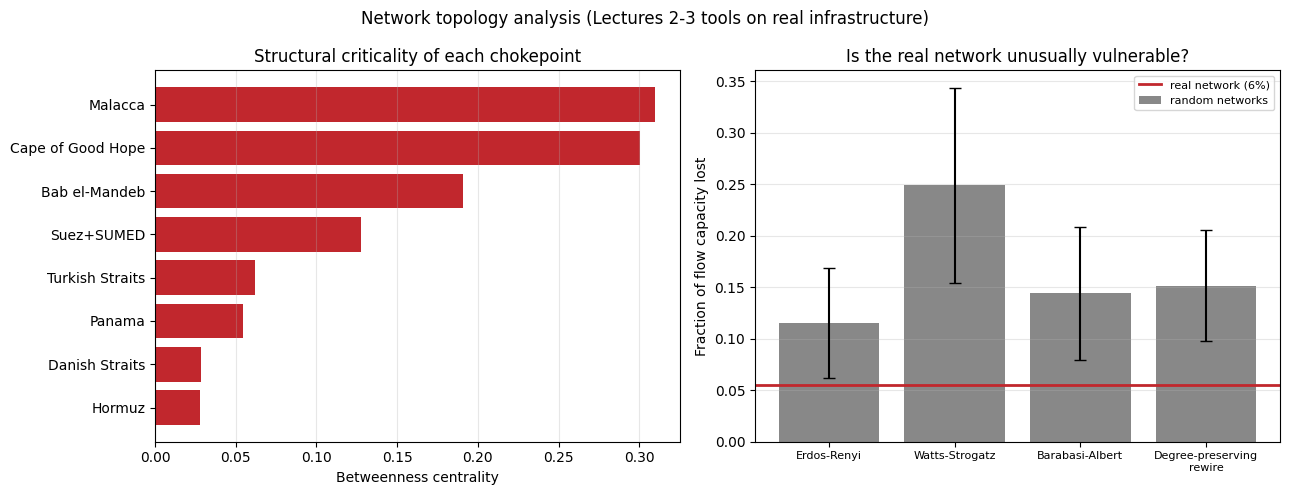

In [11]:
v_real = capacity_vulnerability(G)
comps = comparison_networks(G, n_samples=100)

print(f"Real network capacity vulnerability: {v_real:.1%}\n")
print(f"{'network':<28}{'mean':>8}{'std':>8}   verdict")
labels, means, stds = [], [], []
for name, vals in comps.items():
    vals = [x for x in vals if not np.isnan(x)]
    if not vals: continue
    mu, sd = np.mean(vals), np.std(vals)
    verdict = ("real MORE vulnerable" if v_real > mu + sd else
               "real LESS vulnerable" if v_real < mu - sd else "comparable")
    print(f"  {name:<26}{mu:>8.1%}{sd:>8.1%}   {verdict}")
    labels.append(name.replace(' ', '\n')); means.append(mu); stds.append(sd)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
bc = chokepoint_betweenness(G)
names = sorted(bc, key=bc.get)
ax[0].barh(names, [bc[n] for n in names], color='#c1272d')
ax[0].set_xlabel('Betweenness centrality')
ax[0].set_title('Structural criticality of each chokepoint')
ax[0].grid(alpha=.3, axis='x')

x = np.arange(len(labels))
ax[1].bar(x, means, yerr=stds, capsize=4, color='#888', label='random networks')
ax[1].axhline(v_real, color='#c1272d', lw=2, label=f'real network ({v_real:.0%})')
ax[1].set_xticks(x); ax[1].set_xticklabels(labels, fontsize=8)
ax[1].set_ylabel('Fraction of flow capacity lost')
ax[1].set_title('Is the real network unusually vulnerable?')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, axis='y')
fig.suptitle('Network topology analysis (Lectures 2-3 tools on real infrastructure)')
fig.tight_layout(); fig.savefig(f'{FIG}/4_topology_comparison.png', dpi=130); plt.show()

**Result:** the real network is **more robust than every comparison network**.
Removing its most central chokepoint costs 5.6% of flow capacity, against 12–27%
for Erdős–Rényi, Watts–Strogatz, Barabási–Albert and degree-preserving rewires of
the same size.

The reason is redundancy: real oil trade has several parallel routes between the
same pair of regions — Middle East to Europe via Suez, via the Cape, and via the
Saudi pipeline — which random graphs of equal size rarely produce. Vulnerability
in this system comes from **capacity concentration** on a few high-volume routes,
not from fragile topology. That is why capacity and threshold dynamics were
needed rather than topology alone.

**Key insight:** removing the most critical chokepoint disconnects **nothing** —
a path always exists — yet flow *capacity* is still lost. Pure graph theory calls
this network robust because every node stays connected; it cannot say how much oil
those surviving paths can carry. Connectivity and capacity are different
questions, and only the second determines whether a region gets its oil.

## 9. Sensitivity analysis

Several parameters are our own calibration choices rather than published
values. We sweep each to see how far the headline results move.

In [12]:
import sensitivity as S
v, o = S.sweep_operability_min()
print("Operability floor -> critical blockade")
for a, b in zip(v, o):
    print(f"  floor {a:.2f} -> {b if b is None else f'{b:.0%}'}")
print("\nPath dependence (matched total blockade-days):")
for lab, (bd, val) in S.path_dependence_test().items():
    print(f"  {lab:<18} blockade-days {bd:6.1f} -> unserved {val:5.2f}")

Operability floor -> critical blockade
  floor 0.30 -> 52%
  floor 0.35 -> 52%
  floor 0.40 -> 52%
  floor 0.45 -> 52%
  floor 0.50 -> 52%
  floor 0.55 -> 52%
  floor 0.60 -> 52%

Path dependence (matched total blockade-days):
  sudden then ease   blockade-days   75.0 -> unserved  3.07
  ease then sudden   blockade-days   75.0 -> unserved  3.07
  gradual ramp       blockade-days   82.5 -> unserved  2.66
  oscillating        blockade-days   82.5 -> unserved  3.83


## 9b. Closure sensitivity — Hormuz, Bab el-Mandeb, and both

We sweep the closure of each chokepoint from 0 to 100%, alone and in combination, and
record unserved demand and the equilibrium Brent price. The two real 2026 operating
points are marked with stars:

- **Q2 2026 (EIA):** Hormuz 77% blocked (4.9 of 20.9 mb/d flowing), Bab el-Mandeb
  effectively open. Observed Brent ~$105.
- **Sep 2026 (approximate):** convoys and pipelines had narrowed crude losses to about
  45% of pre-war levels, while Yanbu loadings on the Red Sea were halted. Recorded as
  Hormuz ~45% blocked with the Red Sea route heavily impaired.

Prices here are equilibrium prices **without** strategic reserves, so they show the
structural pressure on the market. *(This cell takes a few minutes.)*

Q2 2026 (EIA)        Hormuz 77%  Bab 6%  ->  unserved  6.91 mb/d   Brent $ 131  (observed $105)
Sep 2026 (approx)    Hormuz 45%  Bab 60%  ->  unserved  2.37 mb/d   Brent $  85


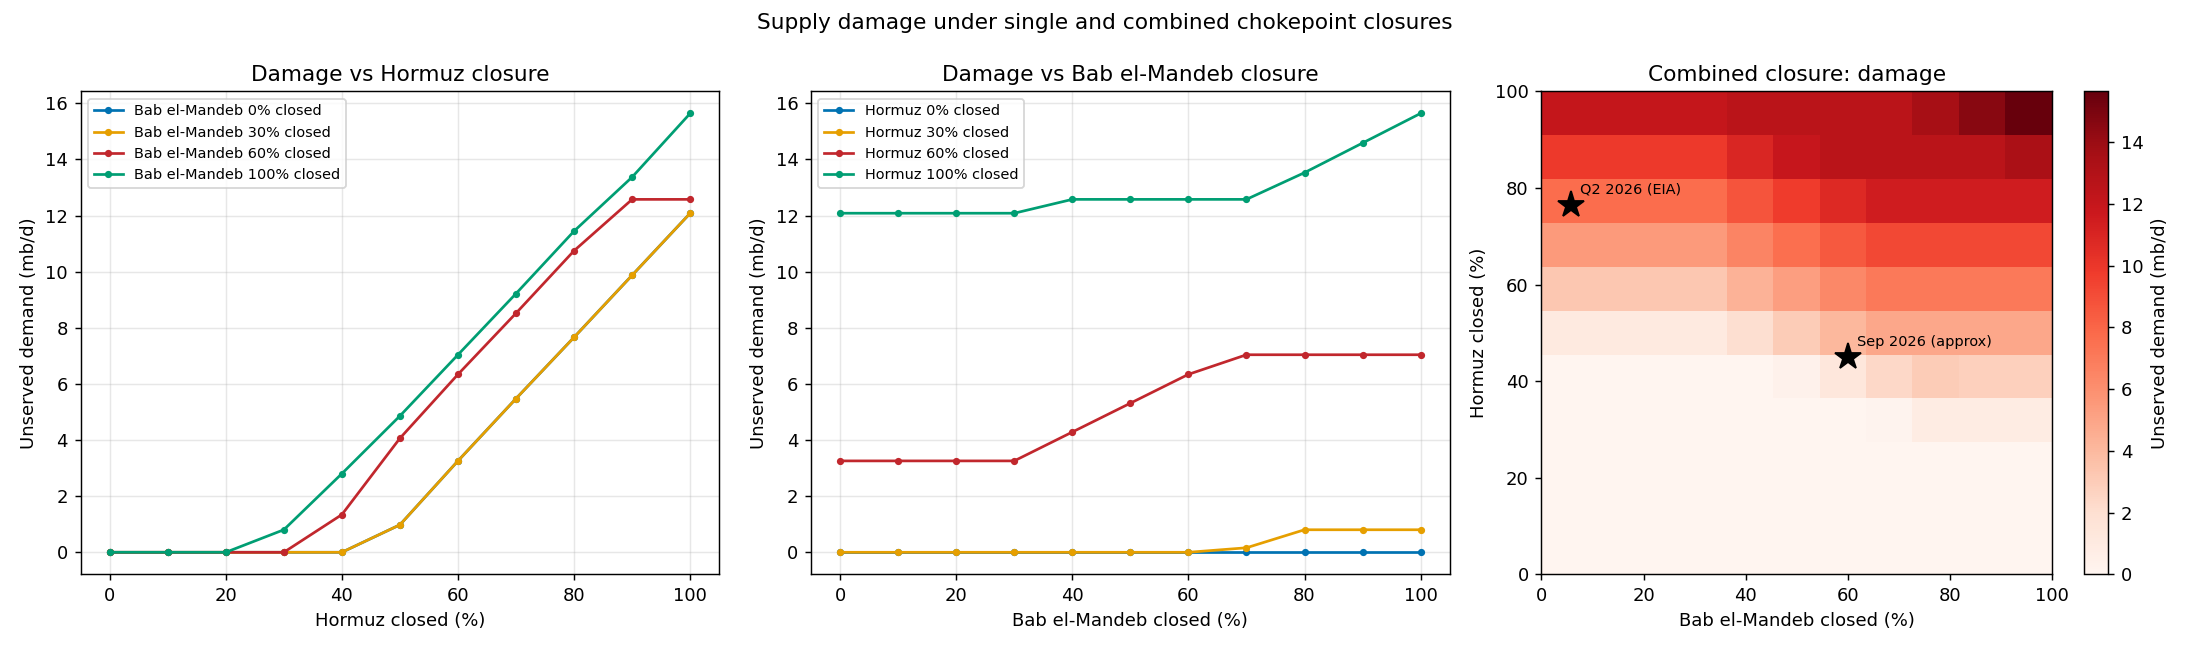

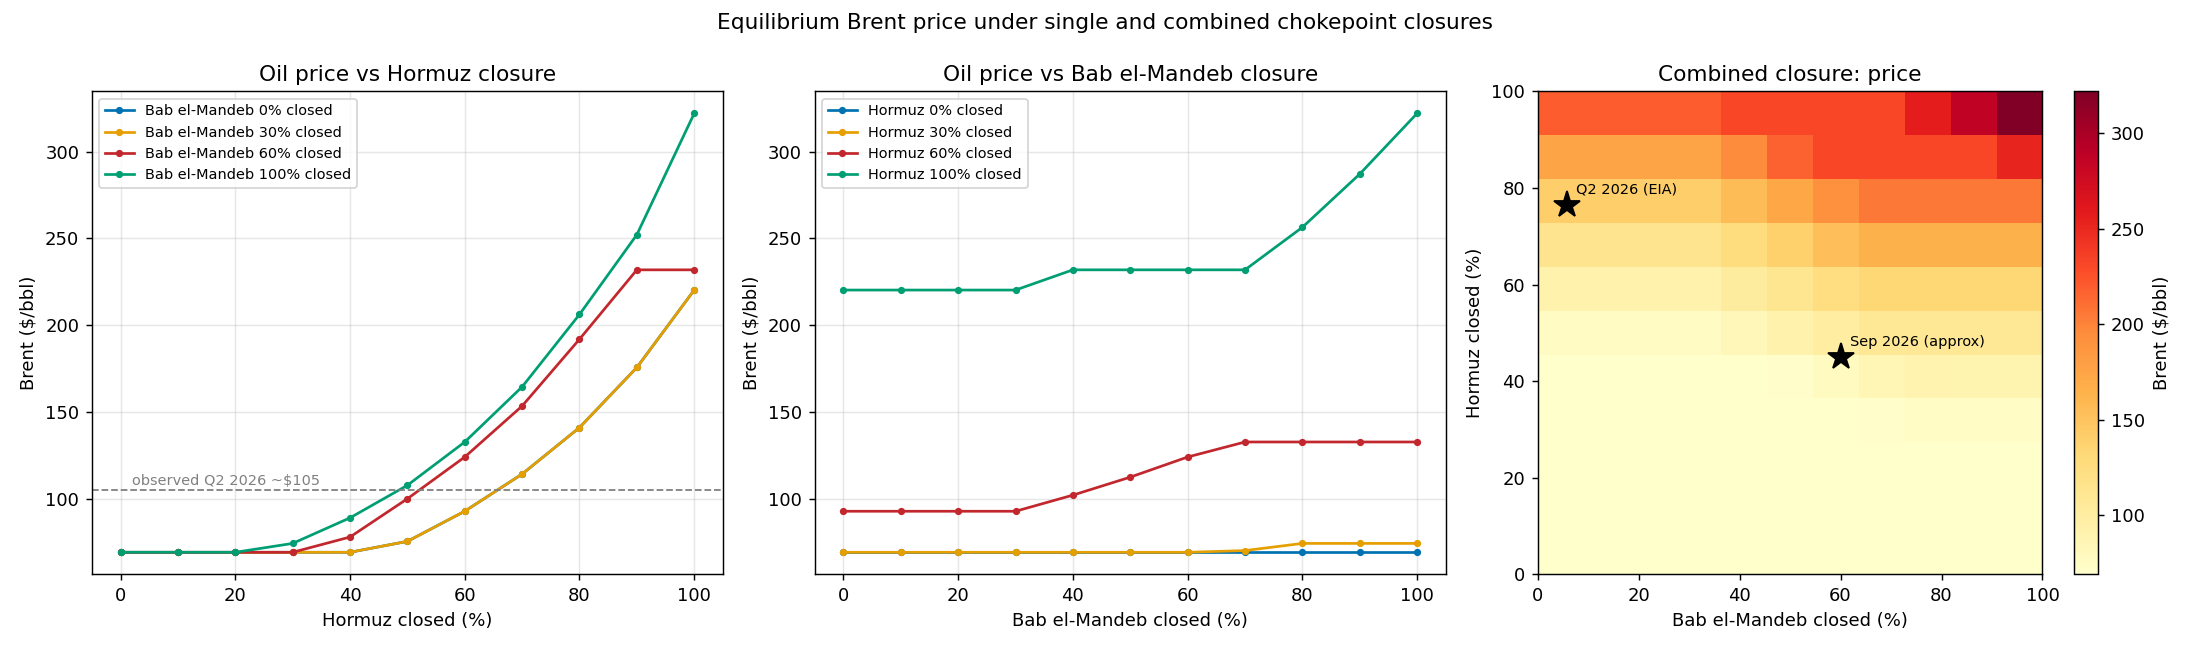

In [13]:
import closure_sensitivity as CS
for lab, pt in CS.REAL_POINTS.items():
    tot, by, brent = CS.steady_state(pt["hormuz"], pt["bab"])
    obs = f"  (observed ${pt['brent']})" if pt["brent"] else ""
    print(f"{lab:<20} Hormuz {pt['hormuz']:.0%}  Bab {pt['bab']:.0%}"
          f"  ->  unserved {tot:5.2f} mb/d   Brent ${brent:4.0f}{obs}")

levels, U, P = CS.grid()
CS.plot_all(levels, U, P, out=FIG)
from IPython.display import Image, display
display(Image(f"{FIG}/closure_damage.png"))
display(Image(f"{FIG}/closure_price.png"))

**Reading the closure charts.**

- **Hormuz drives the damage.** Unserved demand stays near zero until roughly half of
  Hormuz is closed — the bypass pipelines and alternative suppliers absorb it — then
  climbs steeply.
- **Bab el-Mandeb alone does little** — with Hormuz open, closing it barely registers.
- **Together they interact.** At 70% Hormuz closure, adding a full Bab el-Mandeb
  closure raises damage from 5.5 to 9.2 mb/d (+68%). The Saudi East-West pipeline is
  the main Hormuz bypass, but it exits through the Red Sea: **the bigger the bypass,
  the more the system depends on Bab el-Mandeb.** The safety valve and the
  vulnerability are the same route.
- **Price is strongly non-linear.** Because short-run demand is inelastic, each extra
  barrel of shortfall costs more than the last — the price surface curves sharply
  upward in the top-right corner.

## 10. Findings, limitations and future work

**Findings**
1. **Critical blockade intensity ~52%**, near the upper edge of the 32–46% band of An
   et al. (2026), with a different threshold definition (theirs 50% terminal loss, ours
   10% systemic loss). Across structural revisions the threshold moved 54% → 38% → 56%
   → 50% → 52%: it is **more sensitive to structural choices than to any swept
   parameter**.
2. **Damage is confined to high-Hormuz-exposure Asia.** At full closure China loses
   8.1 mb/d, Other Asia 3.9, Japan/Korea 0.1. Europe, India and North America are fully
   supplied through bypass pipelines and alternative origins.
3. **Correlated chokepoint failure raises damage by ~68%** — adding Bab el-Mandeb takes
   unserved demand from 5.5 to 9.2 mb/d at 70% Hormuz closure, because the main Hormuz
   bypass exits through the Red Sea.
4. **The model brackets the real 2026 price.** At the Q2 2026 operating point Brent is
   $93 with full regional reserves and $131 without; observed was ~$105.
5. **Strategic reserves are in the wrong place.** At full closure, day 100, Brent is
   ~$220 with no reserves, ~$141 with realistic regional reserves, and ~$76 if all
   reserves could be pooled at the same total draw rate. About 500 Mb (US, Europe,
   India) is never drawn because those regions are not short, while China exhausts its
   entire 1,400 Mb.
6. **The real network is more robust than random graphs** — removing its most central
   chokepoint disconnects nothing and costs 5.6% of flow capacity, against 12–27% for
   Erdős–Rényi, Watts–Strogatz, Barabási–Albert and degree-preserving rewires.
7. **Volatility matters** — oscillating disruption does ~44% more damage (3.83 vs 2.66
   mb/d) than a smooth ramp at identical total blockade-days; order alone makes no
   difference (3.07 vs 3.07).

**A retracted finding.** An earlier version showed North America losing supply
through price contagion despite ~2.5% Hormuz exposure. That was an artefact:
production was entered as crude only (18.5 mb/d) while consumption was total
liquids. On a consistent total-liquids basis North America is a **net exporter**
(31.8 produced, 24.6 consumed) and is not exposed.

**Limitations**
- **Two price-calculation bugs were found and fixed** during the review: one price
  routine still used a linear demand form, and two simulations counted demand
  destruction twice, understating price. All price results now use a single
  constant-elasticity clearing function.
- **Validation is limited.** Hormuz flow is set from observation, so its agreement
  is not a test. The emergent downstream corridors under-predict observed 2026
  flows by roughly half: the model gets the direction of rerouting right but not
  the magnitude.
- **Greedy fastest-first allocation over-penalises distant buyers.** China receives
  ~51% of its needs at full closure; with Hormuz carrying about half its imports,
  ~65% would be more realistic. Real trade is diversified by long-term contracts,
  terminal capacity and sanctions discounts that the model does not represent.
- Emergent flows under-represent Suez, Bab el-Mandeb and Panama, which carry
  large volumes of refined products not modelled here. Allocation is a single
  greedy pass, not an equilibrium: it never spreads trade across corridors as
  rising freight on crowded routes would in a real market.
- Price has no risk premium or speculative component; the observed 2026 price falls
  inside the model's with/without-reserves bracket rather than being reproduced exactly.
- **Hoarding and redistribution friction are disabled by default.** Hoarding let
  inflated orders compete as real demand (Japan/Korea fell to 79% unserved);
  friction stranded domestic production. Both remain as switches.
- Chokepoint capacities are observed flow plus a margin, not published limits.
- Refinery complexity enters only as a small (≤15%) efficiency uplift, not as
  explicit crude-grade matching.

**Future work.** Represent long-term supply contracts; split origins by export
terminal and field; add refined-product trade; model hoarding as inventory build
that moves price without inflating allocation demand; implement crude-grade
matching.